<a href="https://colab.research.google.com/github/Tesnimma/PotholeDetection/blob/main/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 16.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
from roboflow import Roboflow
from google.colab import userdata
import seaborn as sns
import cv2 as cv
import random
import matplotlib.pyplot as plt
import os

In [3]:
def load_dataset():
  rf = Roboflow(api_key=userdata.get('ROBOFLOW'))
  project = rf.workspace("yeeun-kim-fyvoj").project("pothole-vhmow")
  version = project.version(18)
  dataset = version.download("yolov11")

In [4]:
load_dataset()

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pothole-18 in yolov11:: 100%|██████████| 2610/2610 [00:00<00:00, 3409.29it/s]


In [5]:
len(os.listdir('/content/pothole-18/train/images'))

1302

In [6]:
labels_path=os.listdir('/content/pothole-18/train/labels')

In [7]:
def count_labels(labels_path):
  normal,pothole=0,0
  for path in labels_path :
    absolute_path=os.path.join('/content/pothole-18/train/labels',path)
    with open(absolute_path,'r') as f :
      content=f.readlines()
      if content == [] :
        normal+=1
      else :
        pothole+=1
  return normal,pothole

<BarContainer object of 2 artists>

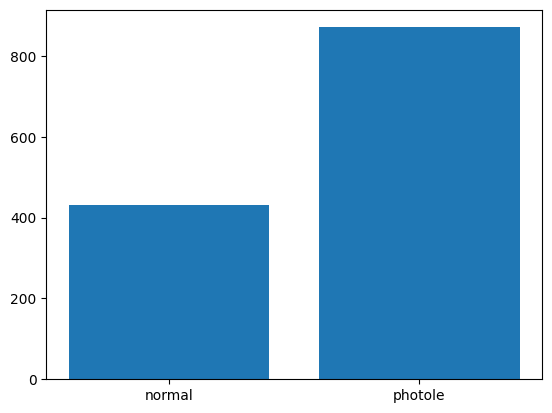

In [8]:
plt.bar(['normal','photole'],count_labels(labels_path))

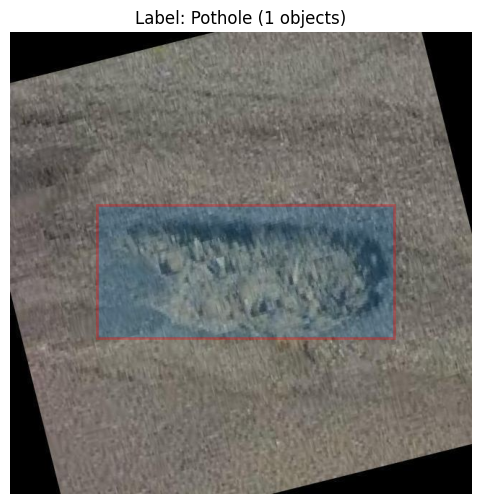

In [9]:
import matplotlib.image as mpimg
from matplotlib.patches import Rectangle

def plot_images_with_labels(images_path, labels_path, number_images=1):
    images = os.listdir(images_path)
    for i in range(number_images):
        image_file = random.choice(images)
        image_path = os.path.join(images_path, image_file)
        label_path = os.path.join(labels_path, image_file.replace('.jpg', '.txt'))

        # Read image
        image = mpimg.imread(image_path)
        h, w, _ = image.shape

        # Display
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis("off")

        # Check if there’s a label
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label_content = f.readlines()
                if label_content == []:
                    plt.title("Label: Normal (no pothole)")
                    continue
                for line in label_content:
                    parts=line.split()
                    class_id=int(parts[0])
                    x_center=float(parts[1])
                    y_center=float(parts[2])
                    width=float(parts[3])
                    height=float(parts[4])

                    # Convert normalized YOLO format to pixel coordinates
                    x_pixel = (x_center - width/2) * w
                    y_pixel = (y_center - height/2) * h
                    width_pixel = width * w
                    height_pixel = height * h

                    rec=Rectangle((x_pixel, y_pixel), width_pixel, height_pixel, edgecolor='red', linewidth=2, alpha=0.3)

                    plt.gca().add_patch(rec)


            plt.title(f"Label: Pothole ({len(label_content)} objects)")
        else:
            plt.title("Label: Normal (no pothole)")
        plt.show()

# Use it:
plot_images_with_labels(
    "/content/pothole-18/train/images",
    "/content/pothole-18/train/labels"
)

In [10]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.1 MB/s eta 0:00:00


In [11]:
def get_shapes(images_path):
  images=os.listdir(images_path)
  shape=set()
  for image in images :
    image_path=os.path.join(images_path,image)
    image=cv.imread(image_path)
    shape.add(image.shape)
  return shape

In [12]:
get_shapes("/content/pothole-18/train/images")

{(640, 640, 3)}

In [13]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [14]:
model = YOLO("yolo11n.pt")

In [15]:
results = model.train(
    data="/content/pothole-18/data.yaml",
    epochs=30,
    imgsz=640
)


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pothole-18/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=

RuntimeError: Dataset '/content/pothole-18/data.yaml' error ❌ Dataset '/content/pothole-18/data.yaml' images not found, missing path '/content/pothole-18/valid/images'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [ ]:
model.export(format="onnx", opset=12)